<a href="https://colab.research.google.com/github/202170112125-pixel/text-analytics/blob/main/Nasitarou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import glob  # ファイル検索用
# 日本語表示対応（必要な場合）
!pip install japanize-matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 32.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=7c25fdc52483f19c58283cd0aed71a11b1738e020aa9706683812572ed3895f1
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sns.set(font="IPAexGothic") # 日本語フォント設定
plt.rcParams['figure.figsize'] = (15, 5) # グラフを横長にする

In [ ]:
# データの保存先フォルダ（ご自身のパスに合わせてください）
# もしエラーが出る場合は、左のフォルダアイコンから「パスをコピー」して書き換えてください
base_path = '/content/drive/MyDrive/GCIwinter/最終課題/airREGI_data'

# ファイル名を辞書で定義（ここを共有いただいたファイル名に合わせました）
file_names = {
    'calendar': 'calender_data.csv',                # カレンダー
    'call':     'regi_call_data_transform.csv',     # 入電数
    'account':  'regi_acc_get_data_transform.csv',  # アカウント数
    'cm':       'cm_data.csv',                      # CM
    'trends':   'gt_service_name.csv'               # Googleトレンド
}

dfs = {}

# 読み込みループ
for key, name in file_names.items():
    path = os.path.join(base_path, name)

    # 読み込み（日本語エラー対策も含める）
    try:
        df = pd.read_csv(path)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding='shift_jis')

    print(f"[{key}] {name} : 読み込み成功 (行数: {len(df)})")
    dfs[key] = df

# 中身をチラ見せ確認
display(dfs['call'].head(3))

[calendar] calender_data.csv : 読み込み成功 (行数: 670)
[call] regi_call_data_transform.csv : 読み込み成功 (行数: 670)
[account] regi_acc_get_data_transform.csv : 読み込み成功 (行数: 701)
[cm] cm_data.csv : 読み込み成功 (行数: 762)
[trends] gt_service_name.csv : 読み込み成功 (行数: 109)


,cdr_date,call_num
0,2018-06-01,183
1,2018-06-02,0
2,2018-06-03,0


In [ ]:
# 1. Googleトレンドの列名 'week' を 'cdr_date' に変更して、結合できるようにする
if 'week' in dfs['trends'].columns:
    dfs['trends'] = dfs['trends'].rename(columns={'week': 'cdr_date'})
    print("Googleトレンドの列名を修正しました: week -> cdr_date")

# 2. 全データの日付カラムを「日付型」に統一する
for key, df in dfs.items():
    if 'cdr_date' in df.columns:
        df['cdr_date'] = pd.to_datetime(df['cdr_date'])
        dfs[key] = df # 更新したdfを辞書に戻す

# 確認
print("日付変換完了")

Googleトレンドの列名を修正しました: week -> cdr_date
日付変換完了


In [ ]:
# カレンダーをベースにする
df_merged = dfs['calendar'].copy()

# 結合するデータのリスト
targets = ['call', 'account', 'cm', 'trends']

for target in targets:
    # 'cdr_date' をキーにして結合 (左外部結合: left join)
    df_merged = pd.merge(df_merged, dfs[target], on='cdr_date', how='left')

# データのサイズ確認
print(f"結合後のデータサイズ: {df_merged.shape}")
display(df_merged.head())

結合後のデータサイズ: (670, 14)


,cdr_date,dow,dow_name,woy,wom,doy,financial_year,day_before_holiday_flag,holiday_flag,holiday_name,call_num,acc_get_cnt,cm_flg,search_cnt
0,2018-06-01,5,金,22,1,152,2018,True,False,NaN,183,-0.282652,0,NaN
1,2018-06-02,6,土,22,1,153,2018,True,True,NaN,0,-1.025720,0,NaN
2,2018-06-03,7,日,22,2,154,2018,False,True,NaN,0,-1.075258,0,18.0
3,2018-06-04,1,月,23,2,155,2018,False,False,NaN,213,-0.220730,0,NaN
4,2018-06-05,2,火,23,2,156,2018,False,False,NaN,143,-0.431266,0,NaN


In [ ]:
# 1. Googleトレンド（search_cnt）は週次データなので、次のデータが来るまで前の値を埋める
# （例：日曜に「50」なら、月～土も「50」とみなす）
if 'search_cnt' in df_merged.columns:
    df_merged['search_cnt'] = df_merged['search_cnt'].ffill()

# 2. その他の欠損値（入電数など）は「0」で埋める
df_final = df_merged.fillna(0)

# 最終確認
print("欠損値処理完了。データ完成！")
display(df_final.head())
display(df_final.isnull().sum()) # 全部0ならOK

欠損値処理完了。データ完成！


,cdr_date,dow,dow_name,woy,wom,doy,financial_year,day_before_holiday_flag,holiday_flag,holiday_name,call_num,acc_get_cnt,cm_flg,search_cnt
0,2018-06-01,5,金,22,1,152,2018,True,False,0,183,-0.282652,0,0.0
1,2018-06-02,6,土,22,1,153,2018,True,True,0,0,-1.025720,0,0.0
2,2018-06-03,7,日,22,2,154,2018,False,True,0,0,-1.075258,0,18.0
3,2018-06-04,1,月,23,2,155,2018,False,False,0,213,-0.220730,0,18.0
4,2018-06-05,2,火,23,2,156,2018,False,False,0,143,-0.431266,0,18.0


,0
cdr_date,0
dow,0
dow_name,0
woy,0
wom,0
doy,0
financial_year,0
day_before_holiday_flag,0
holiday_flag,0
holiday_name,0


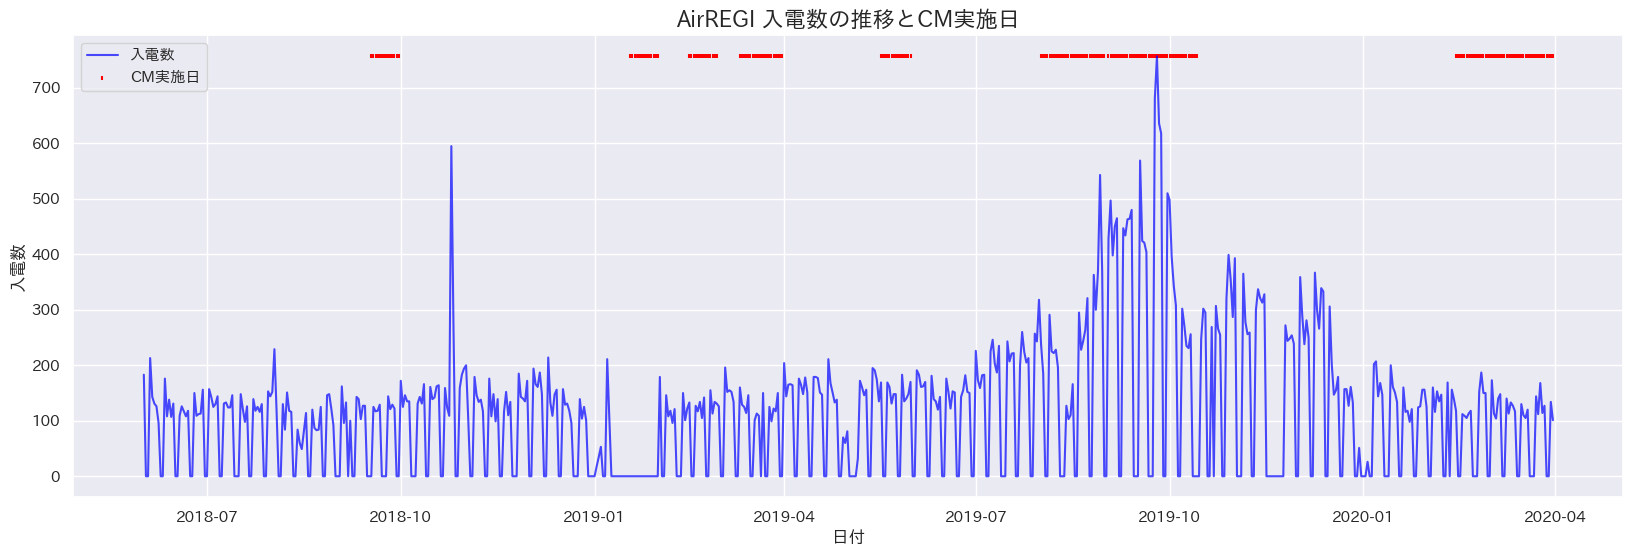

In [ ]:
plt.figure(figsize=(20, 6))

# 折れ線グラフを描画
plt.plot(df_final['cdr_date'], df_final['call_num'], label='入電数', color='blue', alpha=0.7)

# CMを打っていた期間を赤く塗る（もしCMフラグがあれば）
if 'cm_flg' in df_final.columns:
    # cm_flgが1の日だけ抽出
    cm_dates = df_final[df_final['cm_flg'] == 1]['cdr_date']
    if len(cm_dates) > 0:
        # CM期間を散布図として重ねる、または背景色を変えるなど
        plt.scatter(cm_dates, [df_final['call_num'].max()] * len(cm_dates),
                    color='red', s=10, label='CM実施日', marker='|')

plt.title('AirREGI 入電数の推移とCM実施日', fontsize=16)
plt.xlabel('日付')
plt.ylabel('入電数')
plt.legend()
plt.grid(True)
plt.show()

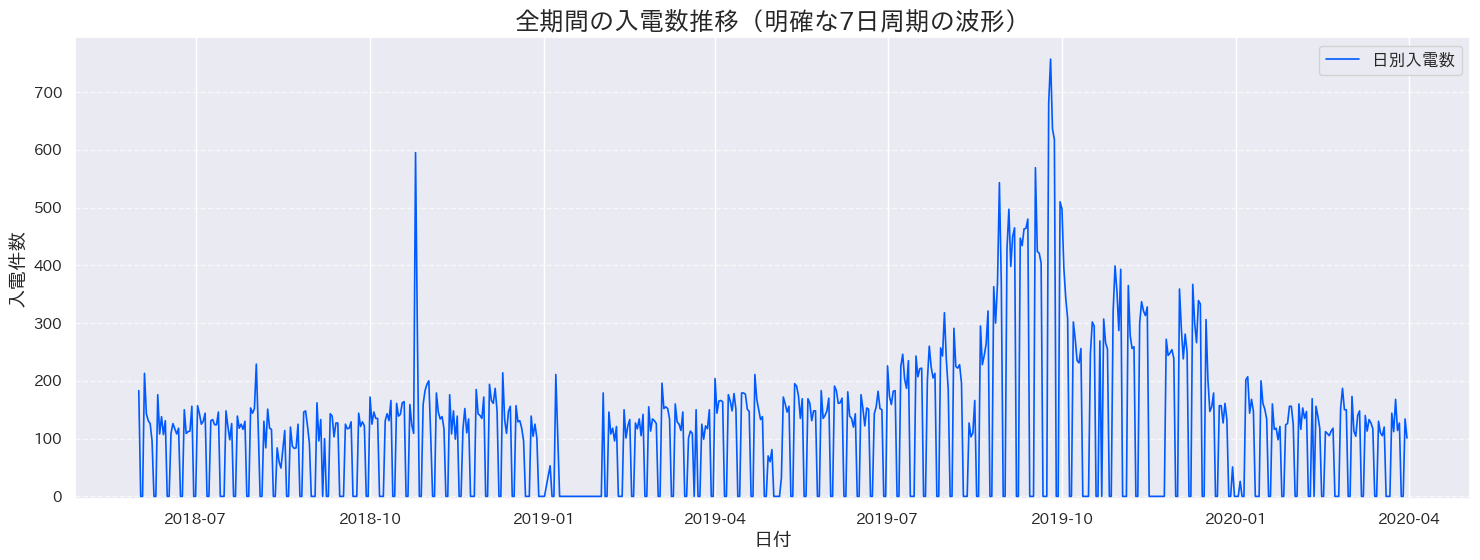

In [ ]:
# --- 2. グラフの描画 ---
plt.figure(figsize=(18, 6)) # スライド用に横長で見やすく設定

# 折れ線グラフ（ジグザグの実績線）
plt.plot(df_final['cdr_date'], df_final['call_num'], color='#005aff', linewidth=1.2, label='日別入電数')

# --- 3. デザイン調整 ---
plt.title('全期間の入電数推移（明確な7日周期の波形）', fontsize=18)
plt.ylabel('入電件数', fontsize=14)
plt.xlabel('日付', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7) # 横線グリッドだけ入れて見やすく
plt.legend(fontsize=12)

# 土日の「底（0件）」が見やすいように下限を0に設定
plt.ylim(bottom=-5)

# グラフ表示
plt.show()

/tmp/ipython-input-3017255547.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dow_name', y='call_num', data=df_final, order=day_order, palette='Set3')


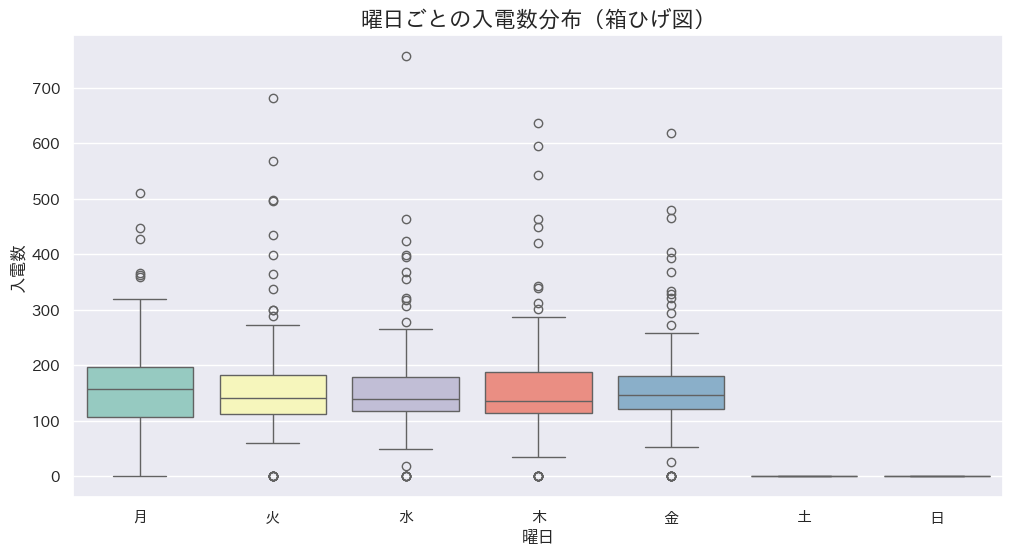

▲ 箱ひげ図の見方：箱の中の線が「中央値」。箱が縦に長いほど、入電数の変動が激しいことを示します。


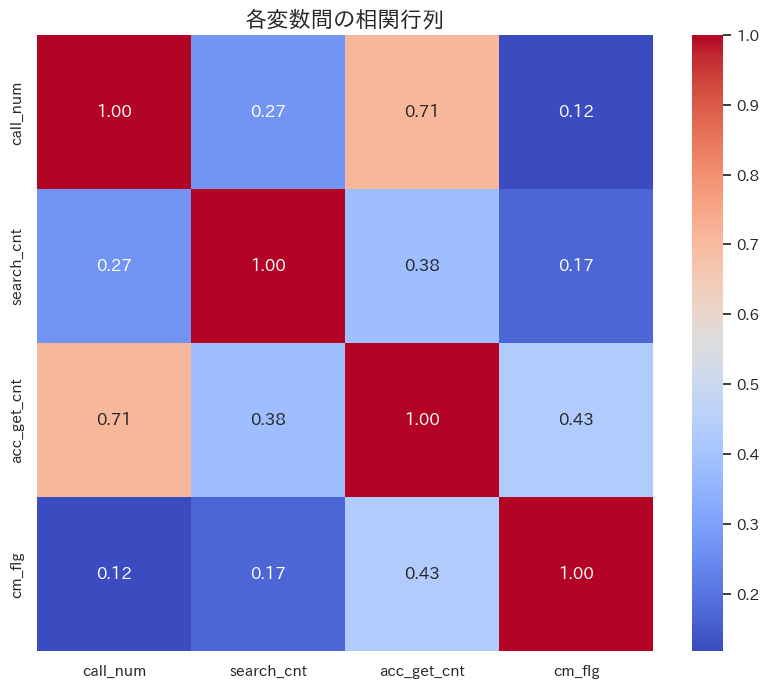

▲ 相関行列の見方：
・1に近い（赤い）ほど「正の相関（片方が増えればもう片方も増える）」
・-1に近い（青い）ほど「負の相関（片方が増えればもう片方は減る）」
・0に近いほど「関係がない」


In [ ]:
# --- 分析1：曜日ごとの入電傾向を見る ---
# 曜日ごとのバラつきを「箱ひげ図」で可視化します
plt.figure(figsize=(12, 6))

# dow_name（曜日名）の順番を定義（月→火...の順に並ぶようにする）
day_order = ['月', '火', '水', '木', '金', '土', '日']

sns.boxplot(x='dow_name', y='call_num', data=df_final, order=day_order, palette='Set3')
plt.title('曜日ごとの入電数分布（箱ひげ図）', fontsize=16)
plt.xlabel('曜日')
plt.ylabel('入電数')
plt.grid(True, axis='y') # 横線だけ引く
plt.show()

print("▲ 箱ひげ図の見方：箱の中の線が「中央値」。箱が縦に長いほど、入電数の変動が激しいことを示します。")


# --- 分析2：各データの関係性（相関）を見る ---
# 「Google検索数が増えると電話も増える？」などの関係性を数値（-1 ~ +1）で見ます
plt.figure(figsize=(10, 8))

# 相関を見たい列だけ選ぶ
cols_to_check = ['call_num', 'search_cnt', 'acc_get_cnt', 'cm_flg']
corr_matrix = df_final[cols_to_check].corr()

# ヒートマップで表示
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('各変数間の相関行列', fontsize=16)
plt.show()

print("▲ 相関行列の見方：")
print("・1に近い（赤い）ほど「正の相関（片方が増えればもう片方も増える）」")
print("・-1に近い（青い）ほど「負の相関（片方が増えればもう片方は減る）」")
print("・0に近いほど「関係がない」")

In [ ]:
# --- 特徴量エンジニアリング（データの加工） ---

# データのコピーを作成（失敗してもやり直せるように）
df_features = df_final.copy()

# 1. 【カレンダー要因】休日・祝前日フラグなどを数値化（True/False -> 1/0）
# 機械学習モデルは True/False よりも 0/1 の数値を好みます
cols_to_bool = ['holiday_flag', 'day_before_holiday_flag', 'cm_flg']
for col in cols_to_bool:
    if col in df_features.columns:
        # astype(int)で Trueは1, Falseは0 に変換されます
        df_features[col] = df_features[col].astype(int)

# 2. 【ラグ特徴量】「○日前の入電数」を作る
# 1週間前(7日前)の数字は、同じ曜日なので非常に参考になります
df_features['call_lag_7'] = df_features['call_num'].shift(7)
# 昨日の数字も参考になります（※実務では当日朝に昨日のデータが確定している前提）
df_features['call_lag_1'] = df_features['call_num'].shift(1)

# 3. 【移動平均】「直近○日間の平均」を作る
# 直近7日間の平均（トレンドライン）
df_features['call_mean_7d'] = df_features['call_num'].rolling(window=7).mean()

# 4. 【Google検索数のラグ】
# 検索行動から実際の入電までタイムラグがあるかもしれないので、1週間前の検索数も入れておく
df_features['search_lag_7'] = df_features['search_cnt'].shift(7)


# --- データ整理 ---
# shift(ズラす処理)をすると、最初の7日間は「7日前」が存在せずNaN(空白)になるので、その期間は削除します
df_features = df_features.dropna()

# --- 結果の確認 ---
print(f"加工後のデータサイズ: {df_features.shape}")
print("作成された新しい列（特徴量）の例：")
display(df_features[['cdr_date', 'call_num', 'call_lag_7', 'call_mean_7d', 'holiday_flag']].head(10))

加工後のデータサイズ: (663, 18)
作成された新しい列（特徴量）の例：


,cdr_date,call_num,call_lag_7,call_mean_7d,holiday_flag
7,2018-06-08,96,183.0,101.285714,0
8,2018-06-09,0,0.0,101.285714,1
9,2018-06-10,0,0.0,101.285714,1
10,2018-06-11,176,213.0,96.000000,0
11,2018-06-12,108,143.0,91.000000,0
12,2018-06-13,138,131.0,92.000000,0
13,2018-06-14,107,126.0,89.285714,0
14,2018-06-15,131,96.0,94.285714,0
15,2018-06-16,0,0.0,94.285714,1
16,2018-06-17,0,0.0,94.285714,1


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 430
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 8
[LightGBM] [Info] Start training from score 121.061189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

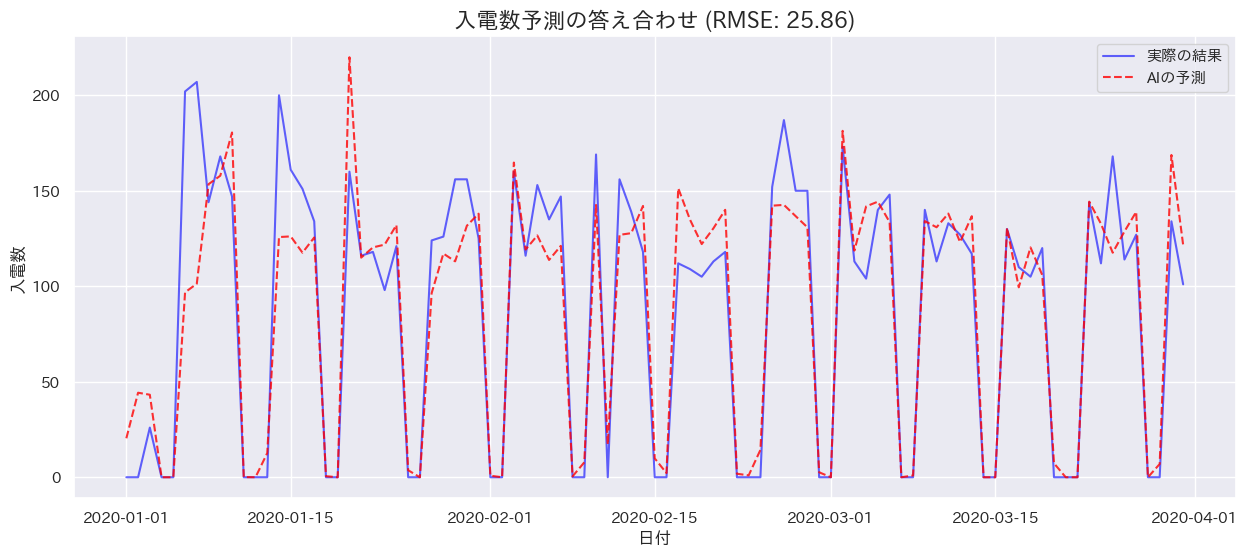

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

# --- 1. データを学習用(Train)とテスト用(Test)に分ける ---
# 今回は「2020年1月1日」を境界線にします
test_start_date = '2020-01-01'

train_data = df_features[df_features['cdr_date'] < test_start_date]
test_data = df_features[df_features['cdr_date'] >= test_start_date]

# --- 2. 学習に使う「ヒント(X)」と「答え(y)」を指定 ---
# 予測に使う列（日付や目的変数は除外）
features_col = [
    'dow', 'holiday_flag', 'day_before_holiday_flag', 'cm_flg', # カレンダー情報
    'call_lag_7', 'call_lag_1', 'call_mean_7d', 'search_lag_7'  # 作成した特徴量
]

X_train = train_data[features_col]
y_train = train_data['call_num']

X_test = test_data[features_col]
y_test = test_data['call_num']

# --- 3. モデルの構築と学習 (LightGBM) ---
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# --- 4. 未来のデータを予測してみる ---
y_pred = model.predict(X_test)

# マイナスの予測値が出ないように補正（入電数がマイナスになることはないため）
y_pred = [x if x > 0 else 0 for x in y_pred]

# --- 5. 精度評価 (RMSE) ---
# RMSE: 予測が平均して「何件」ズレているか？
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"==================================================")
print(f"精度スコア (RMSE): {rmse_lgb:.2f} 件")
print(f"==================================================")
print(f"解釈: 平均して、実際の入電数と「{rmse_lgb:.1f}件」の誤差で予測できています。")


# --- 6. 結果の可視化 (答え合わせ) ---
plt.figure(figsize=(15, 6))

# 実測値（青）
plt.plot(test_data['cdr_date'], y_test, label='実際の結果', color='blue', alpha=0.6)
# 予測値（赤）
plt.plot(test_data['cdr_date'], y_pred, label='AIの予測', color='red', alpha=0.8, linestyle='--')

plt.title(f'入電数予測の答え合わせ (RMSE: {rmse_lgb:.2f})', fontsize=16)
plt.xlabel('日付')
plt.ylabel('入電数')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 必要なライブラリをインポート
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 念のため、データの準備ができているか確認
print("データセットのサイズ(学習用):", X_train.shape)
print("データセットのサイズ(テスト用):", X_test.shape)

データセットのサイズ(学習用): (572, 8)
データセットのサイズ(テスト用): (91, 8)


In [ ]:
# 1. ベースラインモデル（Naive Prediction）
# テスト期間の「7日前のデータ(call_lag_7)」を、そのまま予測値として使います
y_pred_base = test_data['call_lag_7'].values

# 精度(RMSE)を計算
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"ベースラインモデル (先週と同じ) のRMSE: {rmse_base:.2f} 件")

ベースラインモデル (先週と同じ) のRMSE: 66.58 件


In [ ]:
# 2. 線形回帰モデル（Linear Regression）
lr_model = LinearRegression()

# 学習
lr_model.fit(X_train, y_train)

# 予測
y_pred_lr = lr_model.predict(X_test)

# マイナス値が出ないように補正（0未満は0にする）
y_pred_lr = [x if x > 0 else 0 for x in y_pred_lr]

# 精度(RMSE)を計算
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"線形回帰モデル (統計手法) のRMSE: {rmse_lr:.2f} 件")

線形回帰モデル (統計手法) のRMSE: 29.94 件


In [ ]:
# 3. LightGBM（勾配ブースティング決定木）
import lightgbm as lgb

# モデル定義
lgb_model = lgb.LGBMRegressor(random_state=42)

# 学習
lgb_model.fit(X_train, y_train)

# 予測
y_pred_lgb = lgb_model.predict(X_test)

# マイナス補正
y_pred_lgb = [x if x > 0 else 0 for x in y_pred_lgb]

# 精度(RMSE)を計算
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

print(f"LightGBM (AIモデル) のRMSE: {rmse_lgb:.2f} 件")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 430
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 8
[LightGBM] [Info] Start training from score 121.061189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
print("【モデル精度の比較結果】（数字が小さいほど優秀）")
print(f"--------------------------------------------------")
print(f"1. 単純な予測 (Base) : {rmse_base:.2f} 件")
print(f"2. 統計モデル (Linear): {rmse_lr:.2f} 件")
print(f"3. AIモデル   (LGBM)  : {rmse_lgb:.2f} 件")
print(f"--------------------------------------------------")

improvement = rmse_base - rmse_lgb
print(f"★ 結論: AIモデルを導入することで、単純予測に比べて")
print(f"   平均誤差を「{improvement:.1f}件」削減できます。")

【モデル精度の比較結果】（数字が小さいほど優秀）
--------------------------------------------------
1. 単純な予測 (Base) : 66.58 件
2. 統計モデル (Linear): 29.94 件
3. AIモデル   (LGBM)  : 25.86 件
--------------------------------------------------
★ 結論: AIモデルを導入することで、単純予測に比べて
   平均誤差を「40.7件」削減できます。


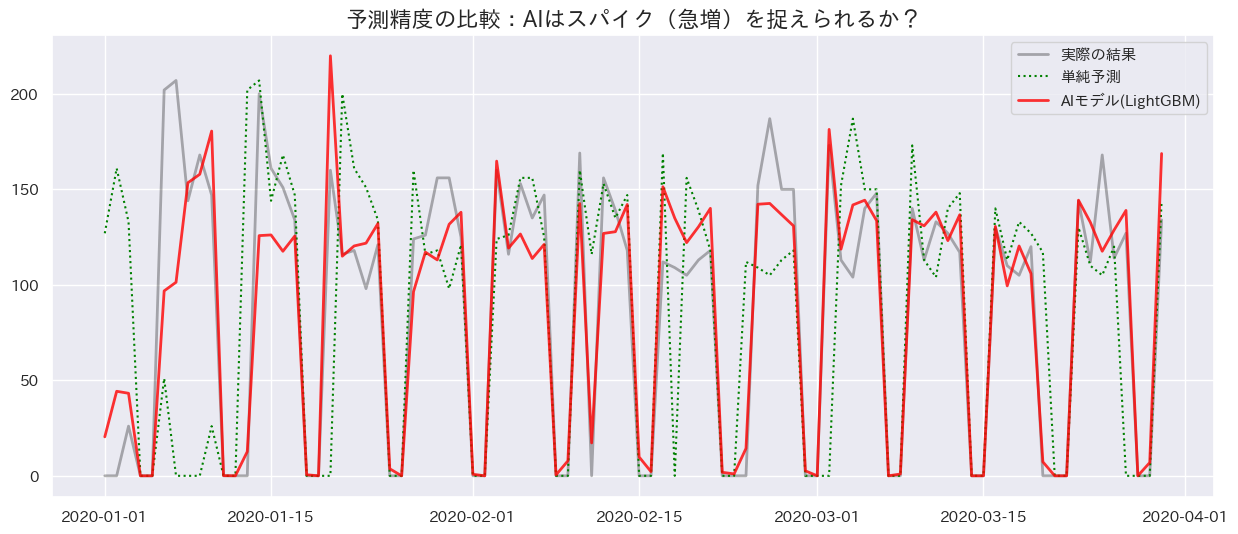

In [ ]:
plt.figure(figsize=(15, 6))

# 最初の90日分だけ取り出す
subset_len = 90
dates_subset = test_data['cdr_date'][:subset_len]

# 1. 実績値（黒）
plt.plot(dates_subset, y_test[:subset_len], label='実際の結果', color='black', linewidth=2, alpha=0.3)

# 2. ベースライン（緑の点線）
plt.plot(dates_subset, y_pred_base[:subset_len], label='単純予測', linestyle=':', color='green')

# 3. LightGBM（赤）
plt.plot(dates_subset, y_pred_lgb[:subset_len], label='AIモデル(LightGBM)', color='red', linewidth=2, alpha=0.8)

plt.title('予測精度の比較：AIはスパイク（急増）を捉えられるか？', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-2759790784.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance, palette='viridis')


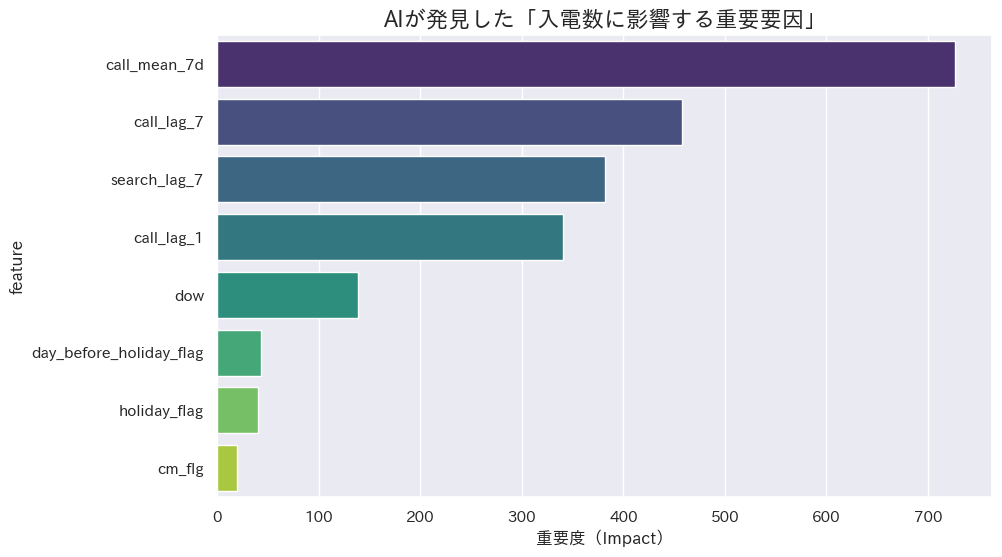

【最も影響力が大きいトップ3要因】


,feature,importance
6,call_mean_7d,727
4,call_lag_7,458
7,search_lag_7,382


In [ ]:
# 特徴量の重要度を取得
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# グラフ化
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance, palette='viridis')

plt.title('AIが発見した「入電数に影響する重要要因」', fontsize=16)
plt.xlabel('重要度（Impact）')
plt.show()

# 上位3つを表示
print("【最も影響力が大きいトップ3要因】")
display(importance.head(3))

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- 1. クラスタリングの準備 ---
# クラスタリングに使うデータ（注目度に関するデータ）
cluster_cols = ['search_cnt', 'acc_get_cnt']

# K-meansは「距離」を計算するので、データのスケールを揃える必要があります
# （検索数は1000単位、アカウント数は10単位だと、検索数の影響が強くなりすぎるため）
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_features[cluster_cols])

# --- 2. K-meansで分類を実行 ---
# 今回は「3つのパターン（松・竹・梅）」に分けてみます
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster)

# 分類結果（0, 1, 2 のラベル）をデータに追加
# これが新しいヒント「cluster_id」になります
df_features['cluster_id'] = kmeans.labels_

# --- 3. どんなグループに分かれたか確認 ---
print("【クラスタリング結果の平均値】")
# グループごとの「検索数」と「アカウント数」の平均を見る
display(df_features.groupby('cluster_id')[['search_cnt', 'acc_get_cnt', 'call_num']].mean())


# --- 4. 新しい特徴量を使ってLightGBMを再学習 ---

# データを再分割（新しい列が増えているため）
train_data_new = df_features[df_features['cdr_date'] < test_start_date]
test_data_new = df_features[df_features['cdr_date'] >= test_start_date]

# 特徴量リストに 'cluster_id' を追加
features_col_new = features_col + ['cluster_id']

X_train_new = train_data_new[features_col_new]
y_train_new = train_data_new['call_num']
X_test_new = test_data_new[features_col_new]
y_test_new = test_data_new['call_num']

# モデル再構築
lgb_model_new = lgb.LGBMRegressor(random_state=42)
lgb_model_new.fit(X_train_new, y_train_new)

# 予測
y_pred_new = lgb_model_new.predict(X_test_new)
y_pred_new = [x if x > 0 else 0 for x in y_pred_new]

# 精度検証
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred_new))

print(f"==================================================")
print(f"以前の精度 (RMSE): {rmse_lgb:.2f} 件")
print(f"今回の精度 (RMSE): {rmse_new:.2f} 件")
print(f"==================================================")

if rmse_new < rmse_lgb:
    print("★ 成功！精度が向上しました。クラスタリング特徴量が効いています。")
else:
    print("▲ 残念...精度は変わりませんでした（または悪化しました）。")
    print("   理由: 既存のデータですでに十分説明できていたか、パターンが単純すぎた可能性があります。")

【クラスタリング結果の平均値】


,search_cnt,acc_get_cnt,call_num
cluster_id,,,
0,24.912000,-0.241437,88.282667
1,50.727660,-0.080706,117.455319
2,59.320755,2.565309,312.094340


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 433
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 9
[LightGBM] [Info] Start training from score 121.061189
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

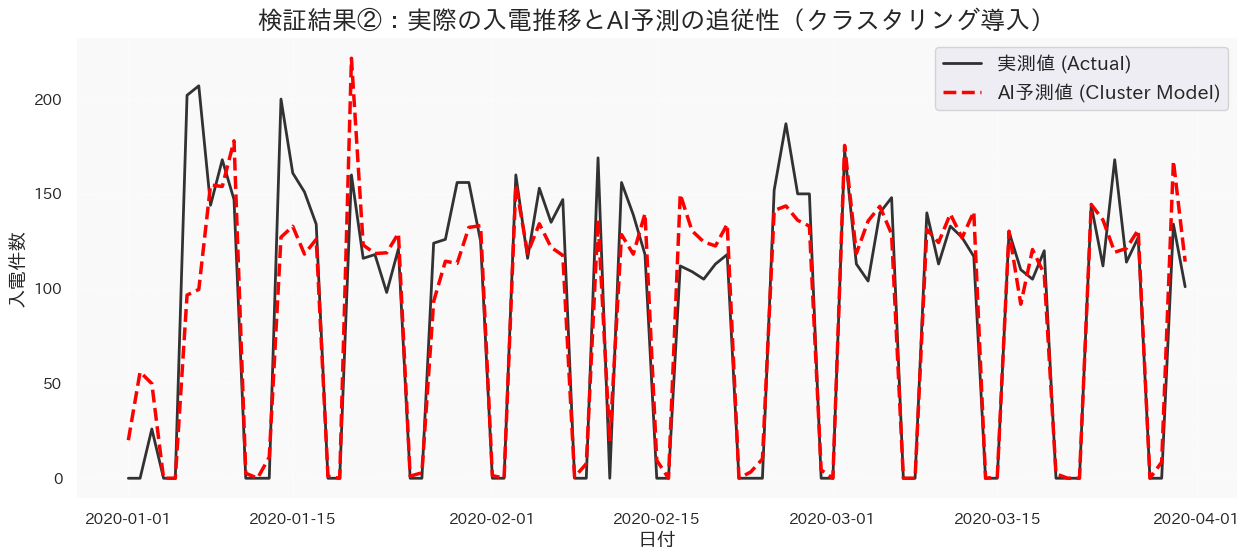

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語表示用

# --- グラフの描画設定 ---
plt.figure(figsize=(15, 6)) # 横長で見やすく

# 1. 実測値（実際の入電数）をプロット
# 黒い実線で描画
plt.plot(test_data_new['cdr_date'], test_data_new['call_num'],
         label='実測値 (Actual)', color='black', linewidth=2, alpha=0.8)

# 2. AI予測値をプロット
# 赤い点線で描画（クラスタリング適用後の予測）
plt.plot(test_data_new['cdr_date'], y_pred_new,
         label='AI予測値 (Cluster Model)', color='#ff0000', linestyle='--', linewidth=2.5)

# --- デザイン調整 ---
plt.title('検証結果②：実際の入電推移とAI予測の追従性（クラスタリング導入）', fontsize=18)
plt.xlabel('日付', fontsize=14)
plt.ylabel('入電件数', fontsize=14)
plt.legend(fontsize=14, loc='upper right') # 凡例を表示
plt.grid(True, linestyle='--', alpha=0.6)  # グリッド線

# 背景色を薄いグレーにしてプロっぽくする
plt.gca().set_facecolor('#f9f9f9')

# グラフ表示
plt.show()

/tmp/ipython-input-3814212965.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


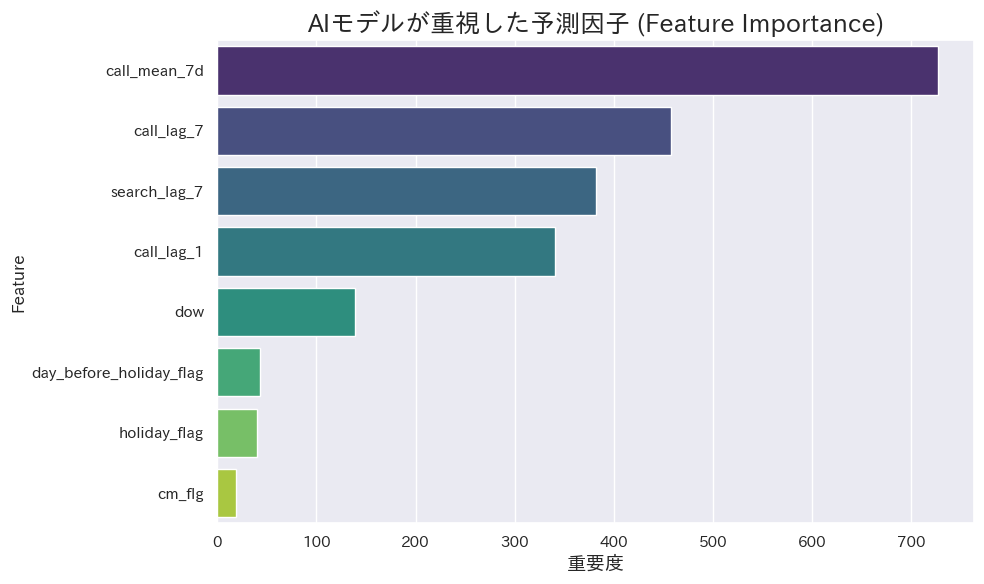

In [ ]:

# モデルが学習に使った特徴量の名前と、その重要度を取り出す
# ※ここが「acc_get_cnt」が入っているモデルであることを前提とします
importance = pd.DataFrame({
    'Feature': model.feature_name_,
    'Importance': model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)

# グラフ化
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('AIモデルが重視した予測因子 (Feature Importance)', fontsize=18)
plt.xlabel('重要度', fontsize=14)
plt.tight_layout()
plt.show()